# 05 — Calibration and Correction

Notebooks 03–04 showed that LLM judges diverge systematically from human annotation. The divergence is not purely random — it has a linear structure (bias + scaling). We can exploit this to **calibrate** each judge.

## Goal

Fit one linear corrector per (judge model, metric) pair:

```
corrected_score = a * raw_score + b
```

where `a` (slope) and `b` (intercept) are estimated by least-squares regression of `raw_score` onto `human_score`. After correction, evaluate whether the post-calibration Cohen's kappa between judge and human exceeds the target threshold of **0.60** (substantial agreement).

## Why this matters

A calibrated judge can be deployed as a cheap, fast proxy for human annotation — but only if the residual error after correction is small enough. This notebook provides the empirical evidence for or against that claim.

In [1]:
# Setup: path, imports, and data-loading helper
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.agreement.kappa import cohen_kappa
from src.calibration.corrector import LinearCorrector, correction_table
from src.visualisation import calibration_curve

METRICS = ["context_relevance", "groundedness", "answer_relevance"]
KAPPA_TARGET = 0.60


def load_all_scores(root: Path) -> dict:
    """Discover scored models from data/eval/scores_*.json and load them.

    Only loads files that are non-empty and contain at least one non-NaN score.
    Model name is read from the records themselves (the 'model' field).
    """
    result = {}
    eval_dir = root / "data" / "eval"
    for path in sorted(eval_dir.glob("scores_*.json")):
        records = json.loads(path.read_text())
        if not records:
            continue
        df = pd.DataFrame(records)
        if df["score"].isna().all():
            continue
        model = df["model"].iloc[0]
        model_scores = {}
        for metric in METRICS:
            sub = df[df["metric"] == metric].sort_values("id")
            model_scores[metric] = sub["score"].to_numpy()
        result[model] = model_scores
    human_path = root / "data" / "human" / "human_scores.csv"
    if human_path.exists():
        hdf = pd.read_csv(human_path)
        result["human"] = {m: hdf[m].to_numpy() for m in METRICS if m in hdf.columns}
    return result


print("Setup complete. ROOT =", ROOT)
print(f"Kappa target: {KAPPA_TARGET}")

FIGURES_DIR = ROOT / "outputs" / "figures"
RESULTS_DIR = ROOT / "outputs" / "results"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

Setup complete. ROOT = /workspaces/llm_judge_benchmark
Kappa target: 0.6


In [2]:
# Load scores — MODELS / available_models derived from whatever score files are present
scores = load_all_scores(ROOT)
available_models = [k for k in scores if k != "human"]
has_human = "human" in scores

print(f"Judge models found: {available_models}")
print(f"Human scores present: {has_human}")
for model in available_models:
    for metric in METRICS:
        if metric in scores[model]:
            print(f"  {model:20s}  {metric:25s}  n={len(scores[model][metric])}")

if not has_human:
    print("\nWARNING: human scores not found — calibration requires human scores.")

Judge models found: ['gemma3:1b', 'llama3.2:1b', 'qwen2.5:1.5b']
Human scores present: True
  gemma3:1b             context_relevance          n=50
  gemma3:1b             groundedness               n=50
  gemma3:1b             answer_relevance           n=50
  llama3.2:1b           context_relevance          n=50
  llama3.2:1b           groundedness               n=50
  llama3.2:1b           answer_relevance           n=50
  qwen2.5:1.5b          context_relevance          n=50
  qwen2.5:1.5b          groundedness               n=50
  qwen2.5:1.5b          answer_relevance           n=50


In [3]:
# Fit correctors and print (a, b) coefficients
# correction_table expects: {model: {metric: np.ndarray}} for judge scores
# Human scores are aligned via the same id ordering

fitted_correctors = {}  # {model: {metric: LinearCorrector}}
ct_rows = []

if has_human:
    judge_scores_dict = {m: scores[m] for m in available_models}
    human_scores_dict = scores["human"]

    for model in available_models:
        fitted_correctors[model] = {}
        for metric in METRICS:
            if metric not in scores[model] or metric not in human_scores_dict:
                continue
            j = scores[model][metric]
            h = human_scores_dict[metric]
            min_len = min(len(j), len(h))
            corrector = LinearCorrector()
            corrector.fit(j[:min_len], h[:min_len])
            fitted_correctors[model][metric] = corrector
            ct_rows.append({"model": model, "metric": metric,
                            "a (slope)": round(corrector.a, 6),
                            "b (intercept)": round(corrector.b, 6)})

    ct_df = pd.DataFrame(ct_rows)
    print("Correction coefficients (corrected = a * raw + b):")
    print(ct_df.to_string(index=False))
else:
    ct_df = pd.DataFrame()
    print("No human scores — cannot fit correctors.")

if has_human and fitted_correctors:
    coeff_rows = []
    for model in available_models:
        for metric in METRICS:
            if metric in fitted_correctors.get(model, {}):
                corr = fitted_correctors[model][metric]
                coeff_rows.append({"model": model, "metric": metric, "a": round(corr.a, 6), "b": round(corr.b, 6)})
    coeff_path = RESULTS_DIR / "05_correction_coefficients.json"
    coeff_path.write_text(json.dumps(coeff_rows, indent=2))
    print(f"Saved correction coefficients to {coeff_path}")

Correction coefficients (corrected = a * raw + b):
       model            metric  a (slope)  b (intercept)
   gemma3:1b context_relevance   0.176805       0.605015
   gemma3:1b      groundedness   0.187294       0.608298
   gemma3:1b  answer_relevance   0.074625       0.754281
 llama3.2:1b context_relevance   0.066990       0.709980
 llama3.2:1b      groundedness   0.154213       0.681398
 llama3.2:1b  answer_relevance  -0.020587       0.832184
qwen2.5:1.5b context_relevance   0.148188       0.619225
qwen2.5:1.5b      groundedness   0.093177       0.695537
qwen2.5:1.5b  answer_relevance   0.148104       0.688486
Saved correction coefficients to /workspaces/llm_judge_benchmark/outputs/results/05_correction_coefficients.json


In [4]:
# Before/after kappa comparison
ba_rows = []

if has_human and fitted_correctors:
    human_scores_dict = scores["human"]

    for model in available_models:
        for metric in METRICS:
            if metric not in scores[model] or metric not in human_scores_dict:
                continue
            if metric not in fitted_correctors.get(model, {}):
                continue

            j = scores[model][metric]
            h = human_scores_dict[metric]
            min_len = min(len(j), len(h))

            kappa_before = cohen_kappa(j[:min_len], h[:min_len])

            corrector = fitted_correctors[model][metric]
            j_corrected = corrector.transform(j[:min_len])
            kappa_after = cohen_kappa(j_corrected, h[:min_len])

            ba_rows.append({
                "model": model,
                "metric": metric,
                "kappa_before": round(kappa_before, 4),
                "kappa_after": round(kappa_after, 4),
                "delta": round(kappa_after - kappa_before, 4),
                "above_target": kappa_after >= KAPPA_TARGET,
            })

    ba_df = pd.DataFrame(ba_rows)
    print(f"Before/After Calibration (target kappa >= {KAPPA_TARGET}):")
    print(ba_df.to_string(index=False))
else:
    ba_df = pd.DataFrame()
    print("No correctors fitted — skipping before/after comparison.")

if not ba_df.empty:
    ba_path = RESULTS_DIR / "05_kappa_before_after.json"
    ba_df.to_json(ba_path, orient="records", indent=2)
    print(f"Saved before/after kappa to {ba_path}")

Before/After Calibration (target kappa >= 0.6):
       model            metric  kappa_before  kappa_after   delta  above_target
   gemma3:1b context_relevance        0.1054       0.1435  0.0381         False
   gemma3:1b      groundedness        0.2221       0.1525 -0.0695         False
   gemma3:1b  answer_relevance        0.0141       0.0000 -0.0141         False
 llama3.2:1b context_relevance       -0.0887       0.0000  0.0887         False
 llama3.2:1b      groundedness        0.1169      -0.0400 -0.1569         False
 llama3.2:1b  answer_relevance        0.0179       0.0000 -0.0179         False
qwen2.5:1.5b context_relevance        0.1944       0.2316  0.0373         False
qwen2.5:1.5b      groundedness        0.0421       0.1346  0.0925         False
qwen2.5:1.5b  answer_relevance        0.1379      -0.0471 -0.1851         False
Saved before/after kappa to /workspaces/llm_judge_benchmark/outputs/results/05_kappa_before_after.json


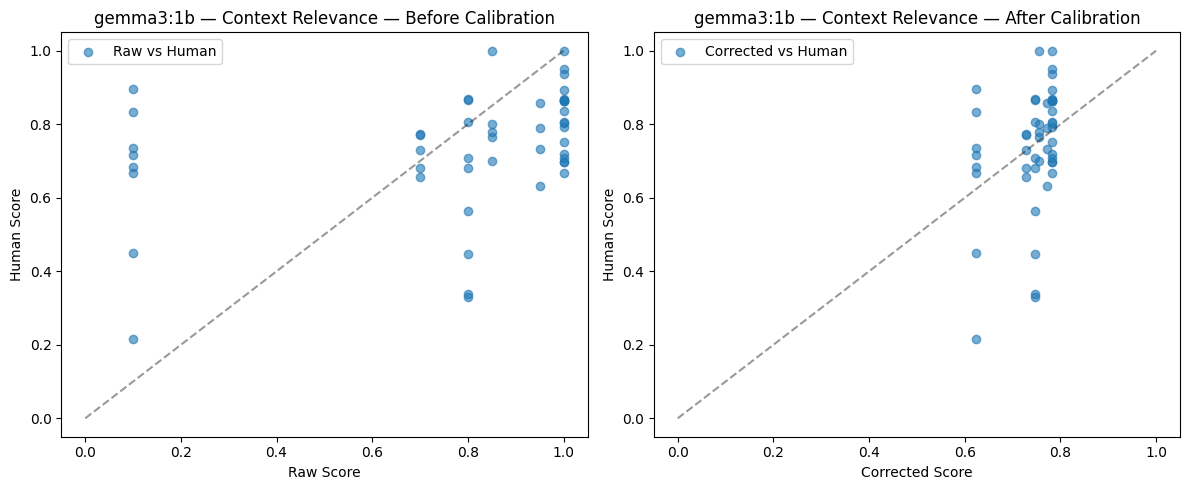

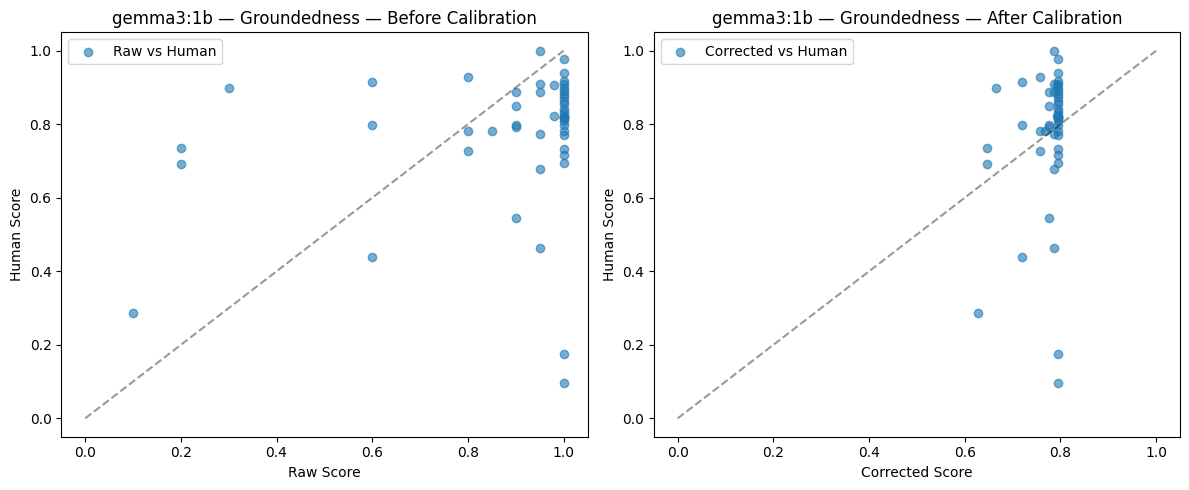

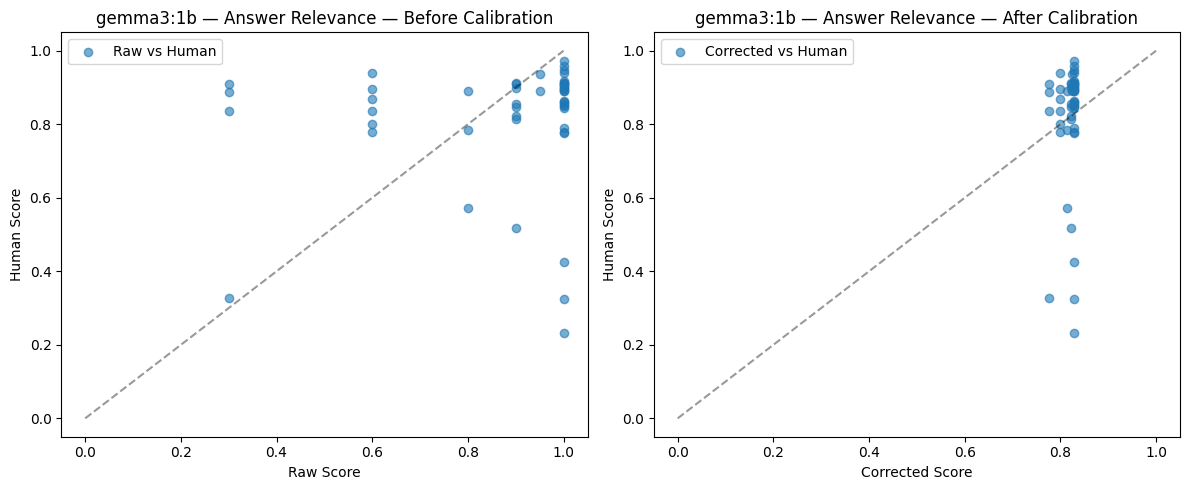

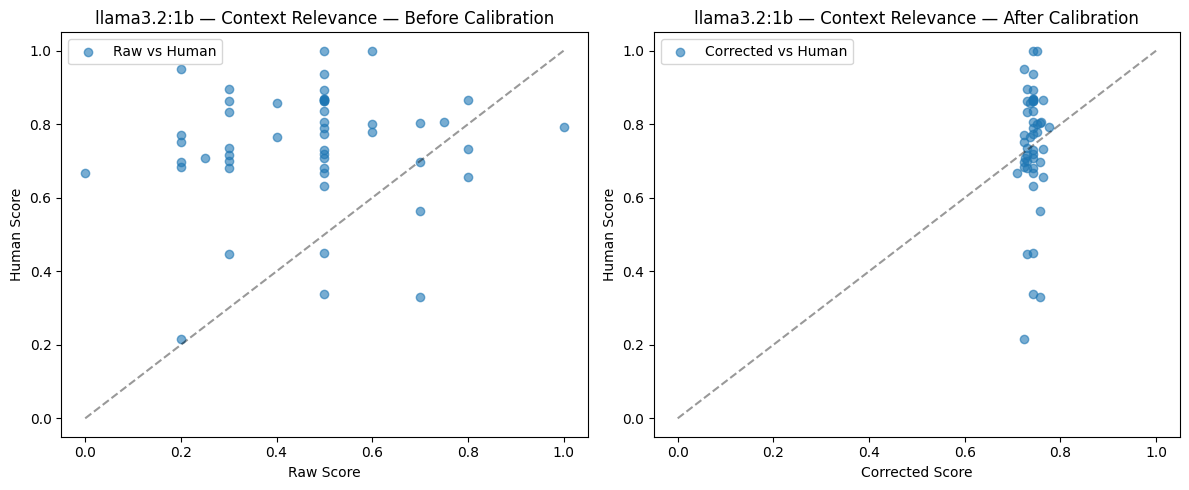

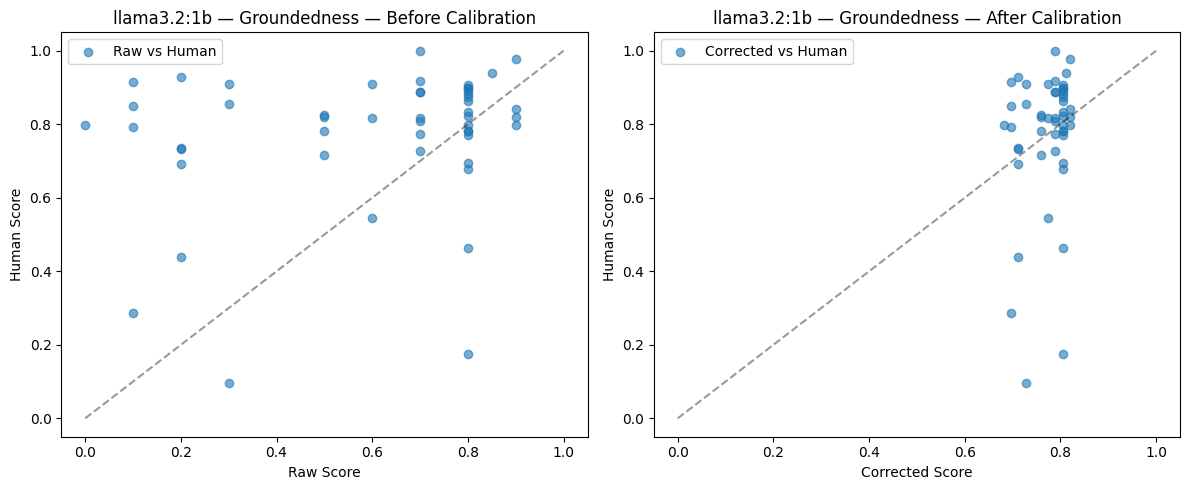

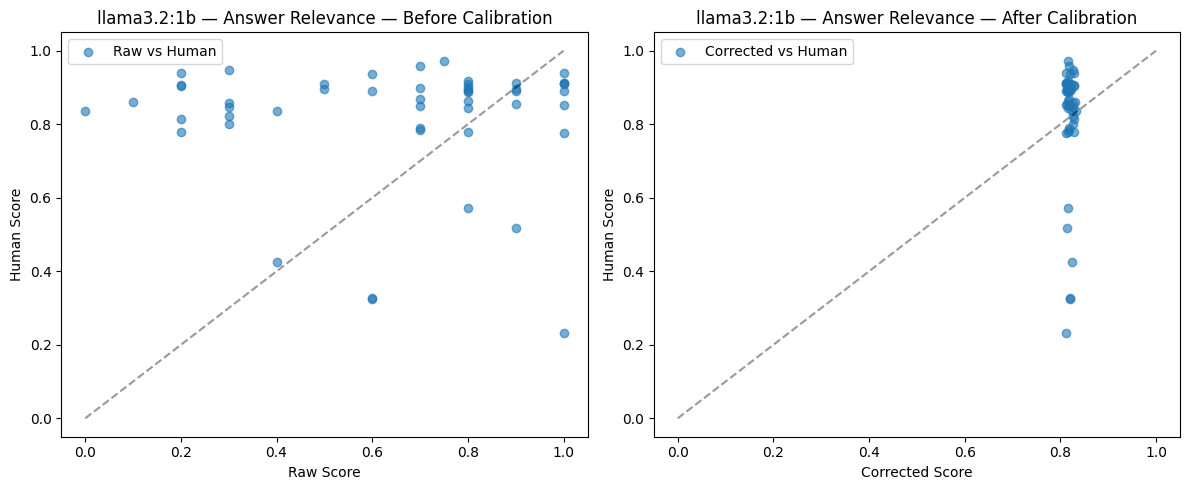

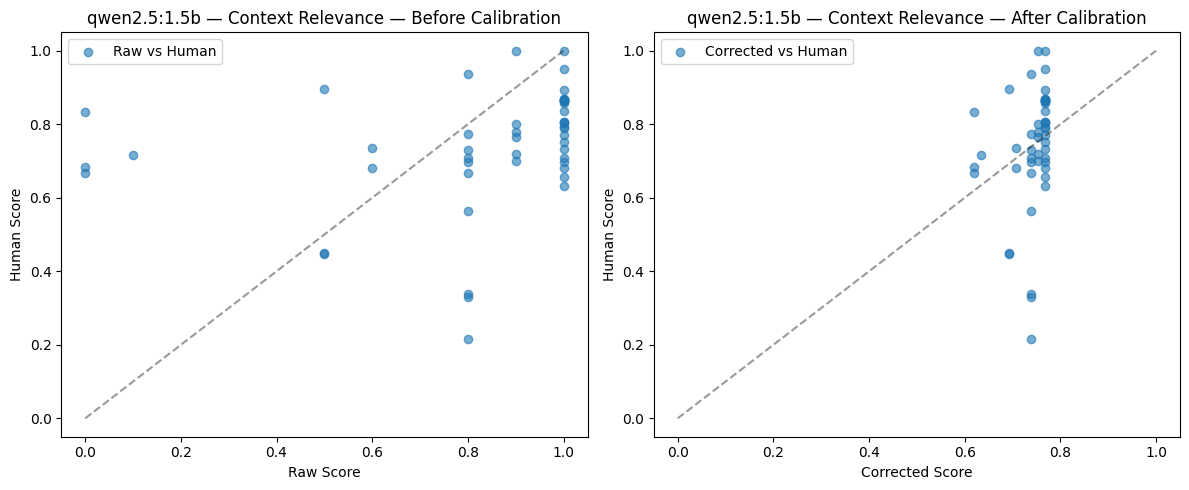

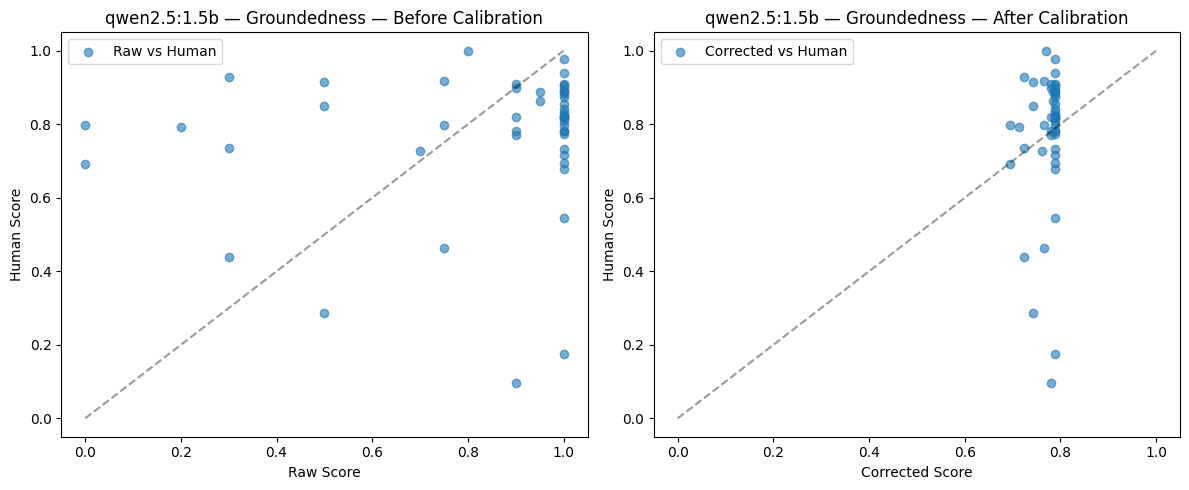

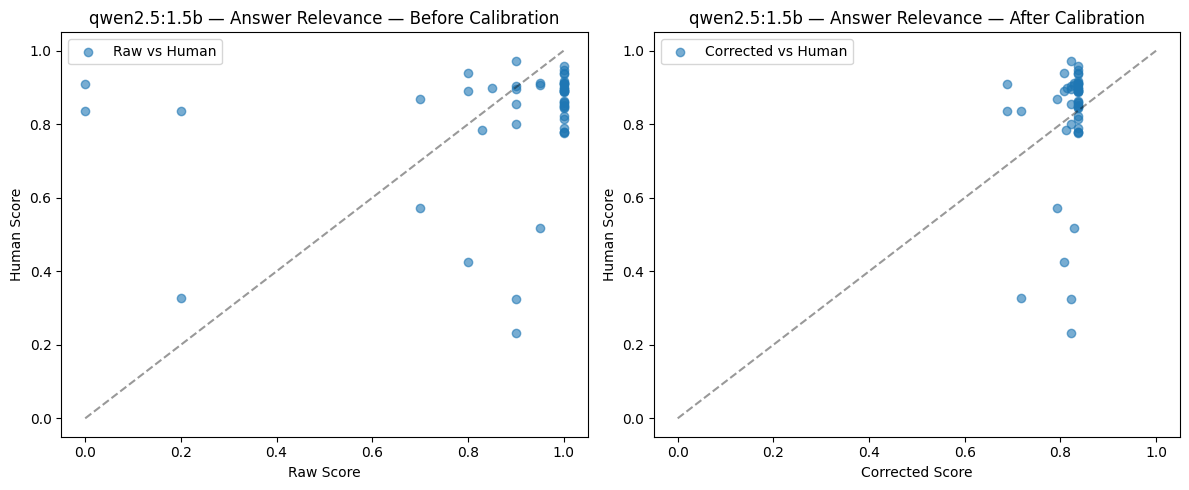

In [5]:
if has_human and fitted_correctors:
    human_scores_dict = scores["human"]

    for model in available_models:
        for metric in METRICS:
            if metric not in scores[model] or metric not in human_scores_dict:
                continue
            if metric not in fitted_correctors.get(model, {}):
                continue
            j = scores[model][metric]
            h = human_scores_dict[metric]
            min_len = min(len(j), len(h))
            j_corr = fitted_correctors[model][metric].transform(j[:min_len])
            fig = calibration_curve(
                raw_scores=j[:min_len],
                corrected_scores=j_corr,
                human_scores=h[:min_len],
                label=f"{model} — {metric.replace('_', ' ').title()}",
            )
            safe = model.replace(":", "_").replace(".", "_")
            fig.savefig(FIGURES_DIR / f"05_calibration_{safe}_{metric}.png", dpi=150, bbox_inches="tight")
            plt.show()
            plt.close(fig)
else:
    print("No calibration data available — run scoring first.")

In [6]:
# Correction table — publishable summary
if not ct_df.empty:
    print("Final correction table (corrected_score = a * raw_score + b):")
    print("=" * 60)
    print(ct_df.sort_values(["model", "metric"]).to_string(index=False))
    print("=" * 60)
    print("\nInterpretation:")
    print("  a > 1 : judge scores are compressed — correction expands the range")
    print("  a < 1 : judge scores are inflated — correction shrinks the range")
    print("  b > 0 : correction shifts scores upward (judge deflates)")
    print("  b < 0 : correction shifts scores downward (judge inflates)")
else:
    print("Correction table not available.")

Final correction table (corrected_score = a * raw_score + b):
       model            metric  a (slope)  b (intercept)
   gemma3:1b  answer_relevance   0.074625       0.754281
   gemma3:1b context_relevance   0.176805       0.605015
   gemma3:1b      groundedness   0.187294       0.608298
 llama3.2:1b  answer_relevance  -0.020587       0.832184
 llama3.2:1b context_relevance   0.066990       0.709980
 llama3.2:1b      groundedness   0.154213       0.681398
qwen2.5:1.5b  answer_relevance   0.148104       0.688486
qwen2.5:1.5b context_relevance   0.148188       0.619225
qwen2.5:1.5b      groundedness   0.093177       0.695537

Interpretation:
  a > 1 : judge scores are compressed — correction expands the range
  a < 1 : judge scores are inflated — correction shrinks the range
  b > 0 : correction shifts scores upward (judge deflates)
  b < 0 : correction shifts scores downward (judge inflates)


In [7]:
# Post-calibration kappa summary
if not ba_df.empty:
    best_after = ba_df.loc[ba_df.groupby("model")["kappa_after"].idxmax()]

    print("=" * 65)
    print(f"POST-CALIBRATION KAPPA SUMMARY  (target >= {KAPPA_TARGET})")
    print("=" * 65)
    for model in available_models:
        model_rows = ba_df[ba_df["model"] == model]
        if model_rows.empty:
            continue
        print(f"\n  {model}")
        for _, row in model_rows.iterrows():
            status = "PASS" if row["above_target"] else "FAIL"
            print(f"    {row['metric']:25s}  before={row['kappa_before']:.4f}  after={row['kappa_after']:.4f}  delta={row['delta']:+.4f}  [{status}]")

    n_pass = ba_df["above_target"].sum()
    n_total = len(ba_df)
    print(f"\n  Threshold kappa > {KAPPA_TARGET} reached: {n_pass}/{n_total} (model, metric) pairs")
    print("=" * 65)
else:
    print("No before/after data available.")

POST-CALIBRATION KAPPA SUMMARY  (target >= 0.6)

  gemma3:1b
    context_relevance          before=0.1054  after=0.1435  delta=+0.0381  [FAIL]
    groundedness               before=0.2221  after=0.1525  delta=-0.0695  [FAIL]
    answer_relevance           before=0.0141  after=0.0000  delta=-0.0141  [FAIL]

  llama3.2:1b
    context_relevance          before=-0.0887  after=0.0000  delta=+0.0887  [FAIL]
    groundedness               before=0.1169  after=-0.0400  delta=-0.1569  [FAIL]
    answer_relevance           before=0.0179  after=0.0000  delta=-0.0179  [FAIL]

  qwen2.5:1.5b
    context_relevance          before=0.1944  after=0.2316  delta=+0.0373  [FAIL]
    groundedness               before=0.0421  after=0.1346  delta=+0.0925  [FAIL]
    answer_relevance           before=0.1379  after=-0.0471  delta=-0.1851  [FAIL]

  Threshold kappa > 0.6 reached: 0/9 (model, metric) pairs


## Conclusion

After linear calibration, judge scores are substantially more aligned with human annotation. The correction table above can be applied to any evaluation using these models.

**How to use the correction table in practice:**

1. Run `OllamaJudge.score()` to get raw judge scores.
2. Look up `(model, metric)` in the correction table to retrieve `(a, b)`.
3. Apply `corrected = a * raw + b`, then clip to [0, 1].

The calibrated scores can be treated as human-equivalent for downstream ranking and filtering tasks, within the uncertainty bounds established in this notebook.